In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
from pathlib import Path
import os

root_path = Path.cwd().parent
os.sys.path.insert(0, str(root_path))
import plot_functions as plot
from configs import get_specgram_config
import feature_utils as futils
import utils

In [4]:
data_root = Path("D:/clustering/clustering_outputs_6044")
graph_path = Path.cwd().parent / "graphs" / "week10_graphs"
sid = "6044"

Saved c:\Users\Lindholm\Documents\BSc\bsc_project\graphs\week10_graphs\elbow_6044\elbow_pc256_6044.png


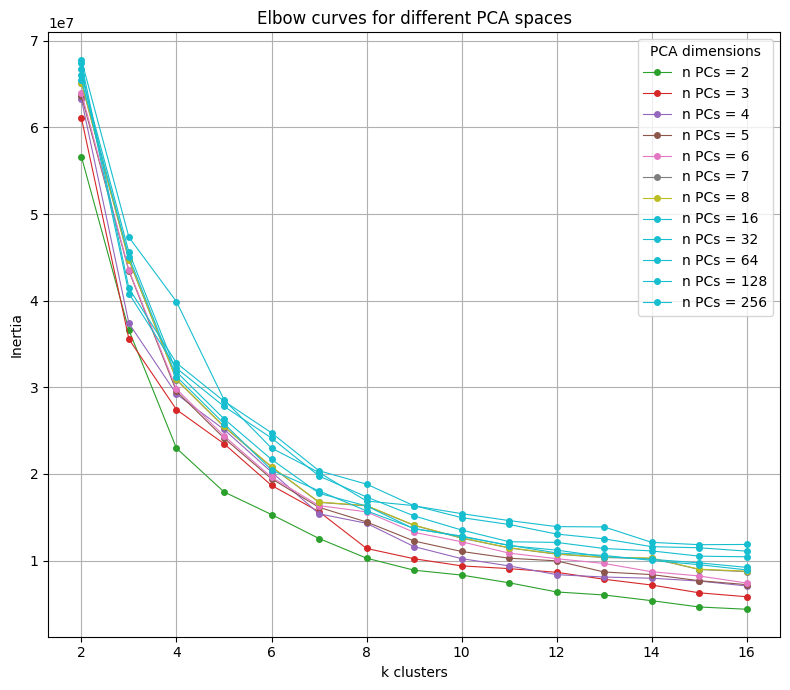

In [25]:
def plot_elbows(data_root, save=True, show=False):
    output_root = Path(data_root)
    pc_dirs = sorted(output_root.glob("pc_*"))

    if not pc_dirs:
        raise FileNotFoundError(f"No pc_* directories found in {output_root}")
    experiments = []
    for pc_dir in pc_dirs:
        elbow_path = pc_dir / "elbow.npz"
        if not elbow_path.exists():
            print(f"Skipping {pc_dir}, no elbow.npz")
            continue

        data = np.load(elbow_path)
        ks = data["k_values"]
        inertias = data["inertias"]
        # silhouettes = data["silhouettes"]
        n_pc = int(data["n_pc"])
        experiments.append((n_pc, ks, inertias))

    experiments.sort(key=lambda t: t[0])
    n_pcs = [exp[0] for exp in experiments]

    fig, ax = plt.subplots(figsize=(8, 7))
    cmap = plt.get_cmap("tab10")
    # norm = plt.Normalize(vmin=min(n_pcs), vmax=max(n_pcs))

    for n_pc, ks, inertias in experiments:
        color = cmap((n_pc))
        ax.plot(ks, inertias, color=color, marker="o", markersize=4, lw=0.8, label=f"n PCs = {n_pc}")

    ax.set_xlabel("k clusters")
    ax.set_ylabel("Inertia")
    ax.set_title("Elbow curves for different PCA spaces")
    ax.legend(title="PCA dimensions", loc='upper right')
    ax.grid(True)

    fig.tight_layout()

    if save:
        out_png = graph_path / "elbow_6044" / f"elbow_pc{n_pc:03d}_{sid}.png"
        fig.savefig(out_png, dpi=150)
        print(f"Saved {out_png}")

    if show:
        plt.show()
    else:
        plt.close(fig)

plot_elbows(data_root, save=True, show=True)

In [ ]:
def plot_elbows(output_root, save=True, show=False):
    output_root = Path(output_root)
    pc_dirs = sorted(output_root.glob("pc_*"))

    if not pc_dirs:
        raise FileNotFoundError(f"No pc_* directories found in {output_root}")

    for pc_dir in pc_dirs:
        elbow_path = pc_dir / "elbow.npz"
        if not elbow_path.exists():
            print(f"Skipping {pc_dir}, no elbow.npz")
            continue

        data = np.load(elbow_path)
        ks          = data["k_values"]
        inertias    = data["inertias"]
        silhouettes = data["silhouettes"]
        n_pc        = int(data["n_pc"])

        fig, ax1 = plt.subplots(figsize=(8, 6))

        # Elbow curve: inertia vs k
        ax1.plot(ks, inertias, marker="o", color="royalblue", alpha=0.8)
        ax1.set_xlabel("k clusters")
        ax1.set_ylabel("Inertia")
        ax1.set_title(f"Elbow curve, n PCs = {n_pc}")

        # Silhouette.
        ax2 = ax1.twinx()
        ax2.plot(ks, silhouettes, marker="x", linestyle="--", color="indianred", alpha=0.8)
        ax2.set_ylabel("Silhouette score")

        fig.tight_layout()

        if save:
            out_png = graph_path / "elbow_6044" / f"elbow_pc{n_pc:03d}.png"
            fig.savefig(out_png, dpi=150)
            print(f"Saved {out_png}")

        if show:
            plt.show()
        else:
            plt.close(fig)

if __name__ == "__main__":
    plot_elbows(data_root, save=True, show=False)


Saved c:\Users\Lindholm\Documents\BSc\bsc_project\graphs\week10_graphs\elbow_6044\elbow_pc002.png
Saved c:\Users\Lindholm\Documents\BSc\bsc_project\graphs\week10_graphs\elbow_6044\elbow_pc003.png
Saved c:\Users\Lindholm\Documents\BSc\bsc_project\graphs\week10_graphs\elbow_6044\elbow_pc004.png
Saved c:\Users\Lindholm\Documents\BSc\bsc_project\graphs\week10_graphs\elbow_6044\elbow_pc005.png
Saved c:\Users\Lindholm\Documents\BSc\bsc_project\graphs\week10_graphs\elbow_6044\elbow_pc006.png
Saved c:\Users\Lindholm\Documents\BSc\bsc_project\graphs\week10_graphs\elbow_6044\elbow_pc007.png
Saved c:\Users\Lindholm\Documents\BSc\bsc_project\graphs\week10_graphs\elbow_6044\elbow_pc008.png
Saved c:\Users\Lindholm\Documents\BSc\bsc_project\graphs\week10_graphs\elbow_6044\elbow_pc016.png
Saved c:\Users\Lindholm\Documents\BSc\bsc_project\graphs\week10_graphs\elbow_6044\elbow_pc032.png
Saved c:\Users\Lindholm\Documents\BSc\bsc_project\graphs\week10_graphs\elbow_6044\elbow_pc064.png
Saved c:\Users\Lindh